# Customer Churn & Retention Intelligence System

## Phase 3 — Customer-Level Feature Engineering

### Objective

The objective of this phase is to transform cleaned transaction-level
data into a customer-level modeling dataset.

All predictive features are created using customer activity available
before the observation cutoff date.

The future 180-day period is used only for the churn outcome and is not
used while constructing model features.

In [5]:
#Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR

WindowsPath('c:/Users/ptbha/OneDrive/Desktop/customer-churn-retention-intelligence/data/processed')

In [7]:
#Load processed datasets
df_sales = pd.read_csv(
    PROCESSED_DATA_DIR / "clean_sales_transactions.csv",
    parse_dates=["InvoiceDate"]
)

df_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "customer_returns.csv",
    parse_dates=["InvoiceDate"]
)

churn_labels = pd.read_csv(
    PROCESSED_DATA_DIR / "customer_churn_labels.csv"
)

print("Sales shape:", df_sales.shape)
print("Returns shape:", df_returns.shape)
print("Churn labels shape:", churn_labels.shape)

Sales shape: (779495, 8)
Returns shape: (18390, 8)
Churn labels shape: (4979, 3)


In [8]:
#Set the same modeling cutoff
CHURN_WINDOW_DAYS = 180

dataset_end_date = df_sales["InvoiceDate"].max()

cutoff_date = (
    dataset_end_date
    - pd.Timedelta(days=CHURN_WINDOW_DAYS)
)

print("Dataset end date :", dataset_end_date)
print("Observation cutoff:", cutoff_date)

Dataset end date : 2011-12-09 12:50:00
Observation cutoff: 2011-06-12 12:50:00


In [9]:
#Create observation-period datasets
observation_sales = df_sales[
    df_sales["InvoiceDate"] <= cutoff_date
].copy()

observation_returns = df_returns[
    df_returns["InvoiceDate"] <= cutoff_date
].copy()

print("Observation sales rows:", len(observation_sales))
print("Observation return rows:", len(observation_returns))

print(
    "Observation customers:",
    observation_sales["Customer ID"].nunique()
)

Observation sales rows: 540816
Observation return rows: 13329
Observation customers: 4979


## Feature 1 — Recency

Recency represents the number of days between a customer's most recent purchase and the observation cutoff date.

A larger recency value indicates that the customer has been inactive for a longer period of time.

In [10]:
#Calculate Recency
recency = (
    observation_sales
    .groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index(name="LastPurchaseDate")
)

recency["RecencyDays"] = (
    cutoff_date - recency["LastPurchaseDate"]
).dt.total_seconds() / 86400

recency["RecencyDays"] = (
    recency["RecencyDays"]
    .clip(lower=0)
)

recency.head()

,Customer ID,LastPurchaseDate,RecencyDays
0,12346,2011-01-18 10:01:00,145.117361
1,12347,2011-06-09 13:01:00,2.992361
2,12348,2011-04-05 10:47:00,68.085417
3,12349,2010-10-28 08:23:00,227.185417
4,12350,2011-02-02 16:01:00,129.867361


In [11]:
recency["RecencyDays"].describe()

count    4979.000000
mean      172.988531
std       146.140342
min         0.000000
25%        37.995486
50%       146.964583
75%       252.004861
max       558.121528
Name: RecencyDays, dtype: float64

## Feature 2 — Purchase Frequency

Purchase frequency represents the number of unique sales invoices generated by each customer during the observation period.

Unique invoices are counted rather than transaction rows because one invoice can contain multiple products.

In [12]:
frequency = (
    observation_sales
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="PurchaseFrequency")
)

frequency["PurchaseFrequency"].describe()

count    4979.000000
mean        5.300462
std        10.268067
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       263.000000
Name: PurchaseFrequency, dtype: float64

## Feature 3 — Monetary Value

Monetary value represents the total value of positive-price purchases made by a customer during the observation period.

Zero-price records are excluded from monetary calculations.

In [13]:
observation_sales_value = observation_sales[
    observation_sales["Price"] > 0
].copy()

observation_sales_value["SalesAmount"] = (
    observation_sales_value["Quantity"]
    * observation_sales_value["Price"]
)

In [14]:
monetary = (
    observation_sales_value
    .groupby("Customer ID")["SalesAmount"]
    .sum()
    .reset_index(name="MonetaryValue")
)

monetary["MonetaryValue"].describe()

count      4977.000000
mean       2427.798866
std       10859.441219
min           2.900000
25%         312.930000
50%         758.620000
75%        1962.010000
max      413459.370000
Name: MonetaryValue, dtype: float64

## Feature 4 — Average Order Value

Average order value measures the typical monetary value of a customer's sales invoices during the observation period.

In [15]:
#First calculate invoice values
invoice_values = (
    observation_sales_value
    .groupby(
        ["Customer ID", "Invoice"],
        as_index=False
    )["SalesAmount"]
    .sum()
)

In [16]:
average_order_value = (
    invoice_values
    .groupby("Customer ID")["SalesAmount"]
    .mean()
    .reset_index(name="AverageOrderValue")
)

average_order_value["AverageOrderValue"].describe()

count     4977.000000
mean       373.019479
std        548.120219
min          2.900000
25%        176.271429
50%        280.070000
75%        415.310000
max      14844.766667
Name: AverageOrderValue, dtype: float64

## Feature 5 — Customer Tenure

Customer tenure represents the number of days between the customer's first observed purchase and the observation cutoff date.

This provides information about how long the customer relationship has been observed.

In [17]:
customer_tenure = (
    observation_sales
    .groupby("Customer ID")["InvoiceDate"]
    .min()
    .reset_index(name="FirstPurchaseDate")
)

customer_tenure["CustomerTenureDays"] = (
    cutoff_date
    - customer_tenure["FirstPurchaseDate"]
).dt.total_seconds() / 86400

customer_tenure.head()

,Customer ID,FirstPurchaseDate,CustomerTenureDays
0,12346,2009-12-14 08:34:00,545.177778
1,12347,2010-10-31 14:20:00,223.937500
2,12348,2010-09-27 14:59:00,257.910417
3,12349,2010-04-29 13:20:00,408.979167
4,12350,2011-02-02 16:01:00,129.867361


In [18]:
customer_tenure["CustomerTenureDays"].describe()

count    4979.000000
mean      366.008238
std       157.499588
min         0.034722
25%       241.901389
50%       401.997222
75%       501.923611
max       558.211806
Name: CustomerTenureDays, dtype: float64

## Feature 6 — Product Diversity

Product diversity represents the number of unique products purchased by each customer during the observation period.

Customers purchasing a wider variety of products may show different engagement patterns compared with customers repeatedly buying only a small set of items.

In [19]:
#Unique products per customer
product_diversity = (
    observation_sales
    .groupby("Customer ID")["StockCode"]
    .nunique()
    .reset_index(name="UniqueProducts")
)

product_diversity["UniqueProducts"].describe()

count    4979.000000
mean       70.633661
std        98.199934
min         1.000000
25%        17.000000
50%        40.000000
75%        87.000000
max      2018.000000
Name: UniqueProducts, dtype: float64

## Feature 7 — Average Quantity per Order

Average quantity per order measures the typical number of product units purchased by a customer in each invoice.

In [20]:
invoice_quantity = (
    observation_sales
    .groupby(
        ["Customer ID", "Invoice"],
        as_index=False
    )["Quantity"]
    .sum()
)

average_quantity_per_order = (
    invoice_quantity
    .groupby("Customer ID")["Quantity"]
    .mean()
    .reset_index(name="AverageQuantityPerOrder")
)

average_quantity_per_order[
    "AverageQuantityPerOrder"
].describe()

count     4979.000000
mean       243.428638
std       1442.339517
min          1.000000
25%         87.428571
50%        147.333333
75%        249.000000
max      87167.000000
Name: AverageQuantityPerOrder, dtype: float64

## Feature 8 — Purchase Interval

Purchase interval features describe the time between distinct customer purchase days.

The median and mean purchase gaps help capture each customer's normal buying cycle.

In [21]:
purchase_days = (
    observation_sales[
        ["Customer ID", "InvoiceDate"]
    ]
    .assign(
        PurchaseDay=lambda x:
        x["InvoiceDate"].dt.normalize()
    )
    [["Customer ID", "PurchaseDay"]]
    .drop_duplicates()
    .sort_values(
        ["Customer ID", "PurchaseDay"]
    )
)

purchase_days["PreviousPurchaseDay"] = (
    purchase_days
    .groupby("Customer ID")["PurchaseDay"]
    .shift(1)
)

purchase_days["PurchaseGapDays"] = (
    purchase_days["PurchaseDay"]
    - purchase_days["PreviousPurchaseDay"]
).dt.days

In [22]:
purchase_interval = (
    purchase_days
    .dropna(subset=["PurchaseGapDays"])
    .groupby("Customer ID")["PurchaseGapDays"]
    .agg(
        MedianPurchaseGap="median",
        MeanPurchaseGap="mean"
    )
    .reset_index()
)

purchase_interval.head()

,Customer ID,MedianPurchaseGap,MeanPurchaseGap
0,12346,17.0,57.142857
1,12347,56.5,55.250000
2,12348,70.0,63.333333
3,12349,91.0,91.000000
4,12352,16.0,26.000000


In [23]:
purchase_interval[
    [
        "MedianPurchaseGap",
        "MeanPurchaseGap"
    ]
].describe()

,MedianPurchaseGap,MeanPurchaseGap
count,3354.000000,3354.000000
mean,86.117024,91.739087
std,78.404013,76.066290
min,1.000000,1.000000
25%,32.500000,40.675000
50%,61.000000,70.816667
75%,114.000000,118.312500
max,540.000000,540.000000


## Feature 9 — Return Behaviour

Customer return and cancellation activity is preserved as a behavioural signal.

Return count and returned value may help identify differences between high-engagement customers and customers with problematic purchase patterns.

In [24]:
#Observation-period return features
observation_returns_value = (
    observation_returns.copy()
)

observation_returns_value["ReturnAmount"] = (
    observation_returns_value["Quantity"].abs()
    * observation_returns_value["Price"]
)

return_features = (
    observation_returns_value
    .groupby("Customer ID")
    .agg(
        ReturnTransactionCount=(
            "Invoice",
            "nunique"
        ),
        ReturnedQuantity=(
            "Quantity",
            lambda x: x.abs().sum()
        ),
        ReturnedValue=(
            "ReturnAmount",
            "sum"
        )
    )
    .reset_index()
)

return_features.head()

,Customer ID,ReturnTransactionCount,ReturnedQuantity,ReturnedValue
0,12346,5,74232,77608.20
1,12349,1,5,24.15
2,12352,3,66,960.63
3,12359,3,220,129.80
4,12360,1,1,40.00


In [25]:
#Inspect return feature distributions
return_features[
    [
        "ReturnTransactionCount",
        "ReturnedQuantity",
        "ReturnedValue"
    ]
].describe()

,ReturnTransactionCount,ReturnedQuantity,ReturnedValue
count,2153.000000,2153.000000,2153.000000
mean,2.764979,150.376219,339.660492
std,4.130373,2517.561648,2411.502692
min,1.000000,1.000000,0.420000
25%,1.000000,3.000000,15.930000
50%,2.000000,9.000000,39.350000
75%,3.000000,28.000000,116.740000
max,79.000000,87563.000000,77608.200000


## Build Customer-Level Feature Table

The individual behavioural features are combined into a single customer-level dataset.

The churn-label customer population is used as the base so that every customer eligible for churn prediction is retained.

In [26]:
#Start with eligible customers
customer_features = churn_labels[
    ["Customer ID", "Churn"]
].copy()

print("Starting customers:", len(customer_features))

customer_features.head()

Starting customers: 4979


,Customer ID,Churn
0,13085,0
1,13078,0
2,15362,1
3,18102,0
4,12682,0


In [27]:
#Merge the main features
customer_features = (
    customer_features
    .merge(
        recency[["Customer ID", "RecencyDays"]],
        on="Customer ID",
        how="left"
    )
    .merge(
        frequency,
        on="Customer ID",
        how="left"
    )
    .merge(
        monetary,
        on="Customer ID",
        how="left"
    )
    .merge(
        average_order_value,
        on="Customer ID",
        how="left"
    )
    .merge(
        customer_tenure[
            ["Customer ID", "CustomerTenureDays"]
        ],
        on="Customer ID",
        how="left"
    )
    .merge(
        product_diversity,
        on="Customer ID",
        how="left"
    )
    .merge(
        average_quantity_per_order,
        on="Customer ID",
        how="left"
    )
    .merge(
        purchase_interval,
        on="Customer ID",
        how="left"
    )
    .merge(
        return_features,
        on="Customer ID",
        how="left"
    )
)

print("Customer feature shape:", customer_features.shape)

customer_features.head()

Customer feature shape: (4979, 14)


,Customer ID,Churn,RecencyDays,PurchaseFrequency,MonetaryValue,AverageOrderValue,CustomerTenureDays,UniqueProducts,AverageQuantityPerOrder,MedianPurchaseGap,MeanPurchaseGap,ReturnTransactionCount,ReturnedQuantity,ReturnedValue
0,13085,0,114.953472,7,2295.30,327.900000,558.211806,46,128.571429,57.0,147.666667,2.0,109.0,973.82
1,13078,0,20.028472,41,20857.28,508.714146,558.155556,131,191.268293,12.0,13.794872,29.0,105.0,576.01
2,15362,1,268.092361,2,613.08,306.540000,558.154167,38,184.000000,290.0,290.000000,NaN,NaN,NaN
3,18102,0,2.807639,102,413459.37,4053.523235,558.143056,310,1357.745098,7.0,11.100000,7.0,1229.0,7545.83
4,12682,0,11.970833,32,15947.69,498.365313,558.140278,251,224.718750,15.0,17.612903,1.0,9.0,88.10


In [28]:
#Check missing values
missing_features = pd.DataFrame({
    "MissingCount": customer_features.isna().sum(),
    "MissingPercentage": (
        customer_features.isna().mean() * 100
    ).round(2)
})

missing_features

,MissingCount,MissingPercentage
Customer ID,0,0.00
Churn,0,0.00
RecencyDays,0,0.00
PurchaseFrequency,0,0.00
MonetaryValue,2,0.04
AverageOrderValue,2,0.04
CustomerTenureDays,0,0.00
UniqueProducts,0,0.00
AverageQuantityPerOrder,0,0.00
MedianPurchaseGap,1625,32.64


### Missing Return Features

Customers without return records during the observation period have no observed return activity.

Their return-related features are therefore assigned a value of zero.

In [29]:
return_columns = [
    "ReturnTransactionCount",
    "ReturnedQuantity",
    "ReturnedValue"
]

customer_features[return_columns] = (
    customer_features[return_columns]
    .fillna(0)
)

In [30]:
missing_monetary_customers = customer_features[
    customer_features["MonetaryValue"].isna()
]

missing_monetary_customers[
    [
        "Customer ID",
        "PurchaseFrequency",
        "MonetaryValue",
        "AverageOrderValue"
    ]
]

,Customer ID,PurchaseFrequency,MonetaryValue,AverageOrderValue
1512,14103,1,NaN,NaN
1515,14827,1,NaN,NaN


In [31]:
#Check their transactions
missing_monetary_ids = (
    missing_monetary_customers["Customer ID"]
    .tolist()
)

observation_sales[
    observation_sales["Customer ID"].isin(
        missing_monetary_ids
    )
][
    [
        "Customer ID",
        "Invoice",
        "Description",
        "Quantity",
        "Price",
        "InvoiceDate"
    ]
].sort_values(
    ["Customer ID", "InvoiceDate"]
)

,Customer ID,Invoice,Description,Quantity,Price,InvoiceDate
61085,14103,497819,This is a test product.,5,0.0,2010-02-12 14:58:00
61174,14827,497843,This is a test product.,5,0.0,2010-02-12 15:47:00


In [32]:
#Add repeat-purchase indicator
customer_features["IsRepeatCustomer"] = (
    customer_features["MedianPurchaseGap"]
    .notna()
    .astype(int)
)

print(
    customer_features["IsRepeatCustomer"]
    .value_counts()
)

print(
    customer_features["IsRepeatCustomer"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

IsRepeatCustomer
1    3354
0    1625
Name: count, dtype: int64
IsRepeatCustomer
1    67.36
0    32.64
Name: proportion, dtype: float64


In [33]:
#final checkpoint
print("Feature table shape:", customer_features.shape)

print("\nMissing values:")
print(
    customer_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate Customer IDs:")
print(
    customer_features["Customer ID"]
    .duplicated()
    .sum()
)

print("\nChurn distribution:")
print(
    customer_features["Churn"]
    .value_counts()
)

Feature table shape: (4979, 15)

Missing values:
MeanPurchaseGap            1625
MedianPurchaseGap          1625
MonetaryValue                 2
AverageOrderValue             2
Churn                         0
RecencyDays                   0
Customer ID                   0
CustomerTenureDays            0
PurchaseFrequency             0
AverageQuantityPerOrder       0
UniqueProducts                0
ReturnTransactionCount        0
ReturnedQuantity              0
ReturnedValue                 0
IsRepeatCustomer              0
dtype: int64

Duplicate Customer IDs:
0

Churn distribution:
Churn
0    2577
1    2402
Name: count, dtype: int64


## Missing Feature Treatment

Missing feature values are handled according to their business meaning.

- Customers with only zero-price transactions have no measurable monetary contribution, so their monetary features are assigned zero.
- Customers without return records have already been assigned zero for return-related features.
- Purchase-gap features are unavailable for customers with only one observed purchase day. These customers are identified separately using the IsRepeatCustomer feature.

In [34]:
#Handle the two monetary customers
monetary_columns = [
    "MonetaryValue",
    "AverageOrderValue"
]

customer_features[monetary_columns] = (
    customer_features[monetary_columns]
    .fillna(0)
)

print(
    customer_features[monetary_columns]
    .isna()
    .sum()
)

MonetaryValue        0
AverageOrderValue    0
dtype: int64


In [35]:
#Handle missing purchase gaps
median_purchase_gap = (
    customer_features["MedianPurchaseGap"]
    .median()
)

median_mean_gap = (
    customer_features["MeanPurchaseGap"]
    .median()
)

print(
    "Median value used for MedianPurchaseGap:",
    median_purchase_gap
)

print(
    "Median value used for MeanPurchaseGap:",
    median_mean_gap
)

Median value used for MedianPurchaseGap: 61.0
Median value used for MeanPurchaseGap: 70.81666666666666


In [36]:
customer_features["MedianPurchaseGap"] = (
    customer_features["MedianPurchaseGap"]
    .fillna(median_purchase_gap)
)

customer_features["MeanPurchaseGap"] = (
    customer_features["MeanPurchaseGap"]
    .fillna(median_mean_gap)
)

## Feature 10 — Return Rate

Return rate measures customer return activity relative to purchase frequency.

This helps distinguish customers with occasional returns from customers whose return behaviour represents a larger proportion of their overall transaction activity.

In [37]:
#Return transaction rate
customer_features["ReturnTransactionRate"] = (
    customer_features["ReturnTransactionCount"]
    /
    customer_features["PurchaseFrequency"]
)

customer_features[
    "ReturnTransactionRate"
].describe()

count    4979.000000
mean        0.207618
std         0.361065
min         0.000000
25%         0.000000
50%         0.000000
75%         0.307692
max         4.000000
Name: ReturnTransactionRate, dtype: float64

## Feature 11 — Product Diversity per Order

Product diversity per order measures the variety of unique products purchased relative to the customer's purchase frequency.

In [38]:
customer_features["ProductsPerOrder"] = (
    customer_features["UniqueProducts"]
    /
    customer_features["PurchaseFrequency"]
)

customer_features[
    "ProductsPerOrder"
].describe()

count    4979.000000
mean       17.754752
std        15.899752
min         0.062500
25%         7.759615
50%        14.000000
75%        22.741758
max       220.000000
Name: ProductsPerOrder, dtype: float64

## Feature 12 — Purchase Activity Rate

Purchase activity rate represents the number of purchases relative to the length of the observed customer relationship.

A small constant is used in the denominator to safely handle customers whose first purchase occurs very close to the observation cutoff.

In [39]:
customer_features["PurchaseActivityRate"] = (
    customer_features["PurchaseFrequency"]
    /
    (customer_features["CustomerTenureDays"] + 1)
)

customer_features[
    "PurchaseActivityRate"
].describe()

count    4979.000000
mean        0.016409
std         0.033031
min         0.001789
25%         0.004675
50%         0.009075
75%         0.017223
max         1.036468
Name: PurchaseActivityRate, dtype: float64

In [40]:
print(
    "Customer feature table shape:",
    customer_features.shape
)

print(
    "\nTotal missing values:",
    customer_features.isna().sum().sum()
)

print(
    "\nDuplicate Customer IDs:",
    customer_features["Customer ID"]
    .duplicated()
    .sum()
)

print("\nColumns:")
for column in customer_features.columns:
    print("-", column)

Customer feature table shape: (4979, 18)

Total missing values: 0

Duplicate Customer IDs: 0

Columns:
- Customer ID
- Churn
- RecencyDays
- PurchaseFrequency
- MonetaryValue
- AverageOrderValue
- CustomerTenureDays
- UniqueProducts
- AverageQuantityPerOrder
- MedianPurchaseGap
- MeanPurchaseGap
- ReturnTransactionCount
- ReturnedQuantity
- ReturnedValue
- IsRepeatCustomer
- ReturnTransactionRate
- ProductsPerOrder
- PurchaseActivityRate


In [41]:
customer_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,4979.0,15340.468769,1702.748365,12346.000000,13883.500000,15336.000000,16815.500000,18287.000000
Churn,4979.0,0.482426,0.499741,0.000000,0.000000,0.000000,1.000000,1.000000
RecencyDays,4979.0,172.988531,146.140342,0.000000,37.995486,146.964583,252.004861,558.121528
PurchaseFrequency,4979.0,5.300462,10.268067,1.000000,1.000000,3.000000,6.000000,263.000000
MonetaryValue,4979.0,2426.823650,10857.368525,0.000000,312.775000,756.700000,1960.305000,413459.370000
AverageOrderValue,4979.0,372.869642,548.061082,0.000000,176.174000,280.026667,415.198750,14844.766667
CustomerTenureDays,4979.0,366.008238,157.499588,0.034722,241.901389,401.997222,501.923611,558.211806
UniqueProducts,4979.0,70.633661,98.199934,1.000000,17.000000,40.000000,87.000000,2018.000000
AverageQuantityPerOrder,4979.0,243.428638,1442.339517,1.000000,87.428571,147.333333,249.000000,87167.000000
MedianPurchaseGap,4979.0,77.919562,65.415967,1.000000,44.000000,61.000000,83.750000,540.000000


In [42]:
feature_file = (
    PROCESSED_DATA_DIR
    / "customer_features.csv"
)

customer_features.to_csv(
    feature_file,
    index=False
)

print(
    "Customer feature dataset saved:",
    feature_file
)

Customer feature dataset saved: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed\customer_features.csv


## Feature Distribution and Skewness Analysis

Before model training, the distributions of numerical customer features are reviewed for skewness and extreme values.

Retail customer behaviour is naturally heterogeneous, so extreme values are not removed automatically. The analysis is used to identify features that may benefit from transformation during modeling.

In [43]:
#Calculate skewness
feature_columns = [
    col for col in customer_features.columns
    if col not in [
        "Customer ID",
        "Churn",
        "IsRepeatCustomer"
    ]
]

feature_skewness = (
    customer_features[feature_columns]
    .skew()
    .sort_values(ascending=False)
)

feature_skewness

AverageQuantityPerOrder    50.210053
ReturnedQuantity           47.780593
ReturnedValue              32.518965
MonetaryValue              23.738585
PurchaseActivityRate       14.253101
AverageOrderValue          13.640623
PurchaseFrequency          10.640299
ReturnTransactionCount     10.169505
UniqueProducts              6.076344
ProductsPerOrder            3.045458
ReturnTransactionRate       2.736109
MedianPurchaseGap           2.537184
MeanPurchaseGap             2.531698
RecencyDays                 0.763517
CustomerTenureDays         -0.542548
dtype: float64

In [44]:
#Compare churn vs non-churn customers
churn_feature_summary = (
    customer_features
    .groupby("Churn")[feature_columns]
    .median()
    .T
)

churn_feature_summary.columns = [
    "NonChurnMedian",
    "ChurnMedian"
]

churn_feature_summary

,NonChurnMedian,ChurnMedian
RecencyDays,65.128472,227.845833
PurchaseFrequency,5.000000,2.000000
MonetaryValue,1440.580000,407.350000
AverageOrderValue,309.531250,234.672500
CustomerTenureDays,430.025694,373.995139
UniqueProducts,65.000000,25.000000
AverageQuantityPerOrder,173.000000,124.000000
MedianPurchaseGap,61.000000,61.000000
MeanPurchaseGap,70.816667,70.816667
ReturnTransactionCount,1.000000,0.000000


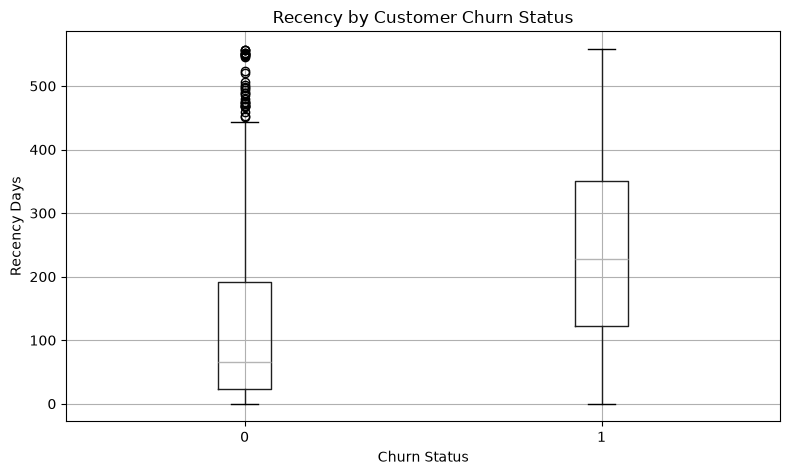

In [50]:
# Recency by churn

ax = customer_features.boxplot(
    column="RecencyDays",
    by="Churn",
    figsize=(8, 5)
)

ax.set_title("Recency by Customer Churn Status")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Recency Days")

plt.suptitle("")
plt.tight_layout()
plt.show()

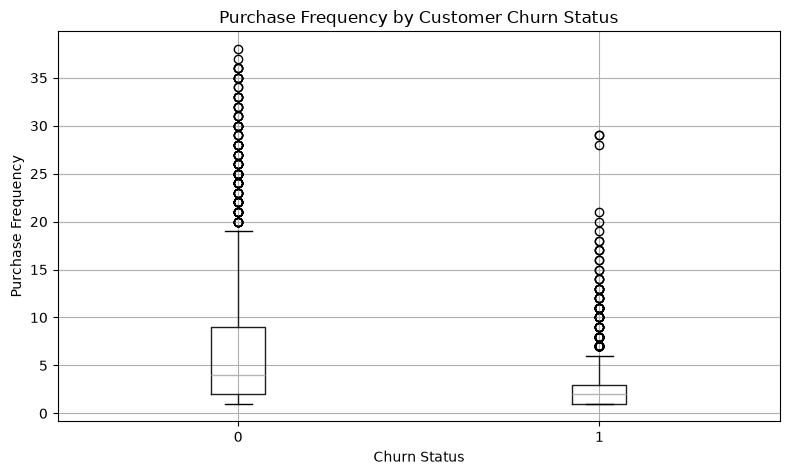

In [51]:
frequency_plot_limit = (
    customer_features["PurchaseFrequency"]
    .quantile(0.99)
)

frequency_plot_data = customer_features[
    customer_features["PurchaseFrequency"]
    <= frequency_plot_limit
]

ax = frequency_plot_data.boxplot(
    column="PurchaseFrequency",
    by="Churn",
    figsize=(8, 5)
)

ax.set_title("Purchase Frequency by Customer Churn Status")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Purchase Frequency")

plt.suptitle("")
plt.tight_layout()
plt.show()

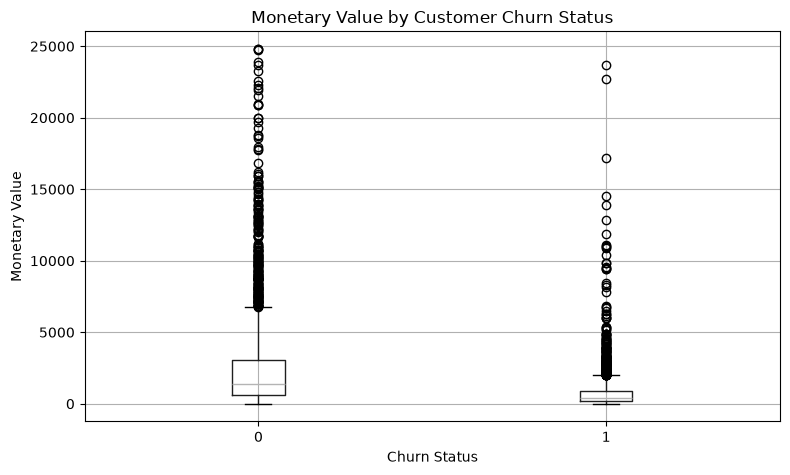

In [52]:
#Monetary value by churn
monetary_plot_limit = (
    customer_features["MonetaryValue"]
    .quantile(0.99)
)

monetary_plot_data = customer_features[
    customer_features["MonetaryValue"]
    <= monetary_plot_limit
]

ax = monetary_plot_data.boxplot(
    column="MonetaryValue",
    by="Churn",
    figsize=(8, 5)
)

ax.set_title("Monetary Value by Customer Churn Status")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Monetary Value")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [48]:
#Repeat-customer churn comparison
repeat_churn = pd.crosstab(
    customer_features["IsRepeatCustomer"],
    customer_features["Churn"],
    normalize="index"
).mul(100).round(2)

repeat_churn

Churn,0,1
IsRepeatCustomer,,
0,25.85,74.15
1,64.31,35.69


In [49]:
#Churn rate by repeat status
repeat_churn_rate = (
    customer_features
    .groupby("IsRepeatCustomer")["Churn"]
    .agg(
        CustomerCount="count",
        ChurnRate="mean"
    )
)

repeat_churn_rate["ChurnRate"] = (
    repeat_churn_rate["ChurnRate"] * 100
).round(2)

repeat_churn_rate

,CustomerCount,ChurnRate
IsRepeatCustomer,,
0,1625,74.15
1,3354,35.69


## Summary

Customer-level feature engineering was completed using only transaction history available before the observation cutoff.

The final dataset contains 4,979 customers with 16 predictive features along with the customer identifier and churn target.

Initial analysis shows clear behavioural differences between churned and non-churned customers. Churned customers generally have higher recency, lower purchase frequency, lower monetary value, and lower purchase activity.

Repeat purchase behaviour also shows a strong relationship with churn. Customers with only one observed purchase day have a churn rate of 74.15%, compared with 35.69% among repeat customers.

Several transaction-based features are highly right-skewed. These features will be handled during model preprocessing rather than removing high-value customers from the dataset.

The completed customer feature dataset has been saved for the modeling phase.